In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):



    """
    A custom residual block that manually implements skip connections
    and handles dimension mismatches using a 1x1 convolution projection.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Second convolution layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection to handle dimension/stride mismatch
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x

        # Main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Manual skip connection connection
        out += self.shortcut(residual)
        out = self.relu(out)

        return out


class CustomResNet(nn.Module):
    """
    A custom ResNet architecture built from scratch.
    Constraints fulfilled:
    - 3 residual stages (within the 2-4 limit)
    - 2 blocks per stage (within the 1-3 limit)
    - Increasing channel depth (64 -> 128 -> 256)
    - Global Average Pooling before the final classifier
    """
    def __init__(self, num_classes=10):
        super(CustomResNet, self).__init__()
        self.in_channels = 64

        # Initial preparation layer for CIFAR-10 (32x32 inputs)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Stage 1: 2 blocks, keeps 64 channels
        self.stage1 = self._make_stage(64, num_blocks=2, stride=1)

        # Stage 2: 2 blocks, increases depth to 128 channels, downsamples spatial size
        self.stage2 = self._make_stage(128, num_blocks=2, stride=2)

        # Stage 3: 2 blocks, increases depth to 256 channels, downsamples spatial size
        self.stage3 = self._make_stage(256, num_blocks=2, stride=2)

        # Global Average Pooling and Linear Classifier
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_stage(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial block
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Residual stages
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)

        # Classification head
        out = self.gap(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out

# --- Verification Check ---
if __name__ == "__main__":
    # Create an instance of the model
    model = CustomResNet(num_classes=10)
    print(model)

    # Generate a dummy batch mimicking CIFAR-10 dimensions (Batch, Channels, Height, Width)
    dummy_input = torch.randn(4, 3, 32, 32)
    output = model(dummy_input)
    print(f"\nInput shape: {dummy_input.shape}")
    print(f"Output shape: {output.shape}")


CustomResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3

### Dataset Loading and Preprocessing

We will use the CIFAR-10 dataset for training and evaluation. Standard transformations will be applied, including converting images to tensors and normalization.

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define transformations for the training and test sets
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Load CIFAR-10 training and test datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Create data loaders
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

# Define the 10 classes in CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training dataset size: {len(trainset)}")
print(f"Test dataset size: {len(testset)}")

100%|██████████| 170M/170M [1:02:13<00:00, 45.7kB/s]


Training dataset size: 50000
Test dataset size: 10000


### Final Accuracy and Classification Report

After training, we will evaluate the model on the test set to get the final accuracy and a detailed classification report, including precision, recall, and F1-score for each class.

In [ ]:
from sklearn.metrics import classification_report

model.eval()
correct = 0
total = 0
all_predicted = []
all_targets = []
with torch.no_grad():
    for data, target in testloader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        all_predicted.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

final_accuracy = 100 * correct / total
print(f'Final Accuracy of the model on the 10000 test images: {final_accuracy:.2f}%')

# Classification report
print('\nClassification Report:')
print(classification_report(all_targets, all_predicted, target_names=classes))

Final Accuracy of the model on the 10000 test images: 82.19%

Classification Report:
              precision    recall  f1-score   support

       plane       0.93      0.76      0.83      1000
         car       0.98      0.86      0.92      1000
        bird       0.60      0.87      0.71      1000
         cat       0.89      0.44      0.59      1000
        deer       0.79      0.89      0.84      1000
         dog       0.76      0.78      0.77      1000
        frog       0.91      0.87      0.89      1000
       horse       0.91      0.84      0.87      1000
        ship       0.80      0.96      0.87      1000
       truck       0.85      0.95      0.90      1000

    accuracy                           0.82     10000
   macro avg       0.84      0.82      0.82     10000
weighted avg       0.84      0.82      0.82     10000



### Confusion Matrix



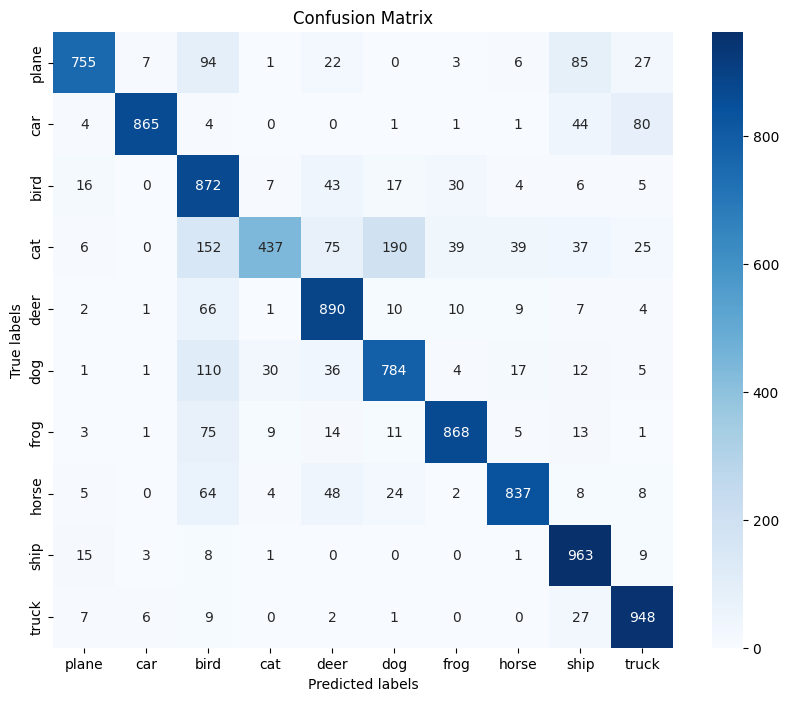

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(all_targets, all_predicted)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

### Save Trained Model Weights



In [ ]:
torch.save(model.state_dict(), 'cifar10_custom_resnet.pth')
print("Model weights saved to cifar10_custom_resnet.pth")

Model weights saved to cifar10_custom_resnet.pth


### Training and Validation Functions



In [ ]:
import torch.optim as optim

def train(model, device, train_loader, optimizer, criterion):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()  # Zero the gradients
        outputs = model(data)  # Forward pass
        loss = criterion(outputs, target)  # Calculate loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def validate(model, device, test_loader, criterion):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # Disable gradient calculation during validation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    avg_loss = running_loss / len(test_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

### Model Training



In [ ]:
import matplotlib.pyplot as plt
import torch # Added import torch

# Device configuration
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model, move to device, define loss function and optimizer
model = CustomResNet(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4) # ResNet typically uses SGD with momentum
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200) # Learning rate scheduler

num_epochs = 10 # You can adjust the number of epochs

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("Starting training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, device, trainloader, optimizer, criterion)
    val_loss, val_acc = validate(model, device, testloader, criterion)
    scheduler.step() # Update learning rate

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print("Training finished.")

Starting training...
Epoch 1/10: Train Loss: 1.3899, Train Acc: 48.87%, Val Loss: 1.1200, Val Acc: 60.53%
Epoch 2/10: Train Loss: 0.9297, Train Acc: 67.10%, Val Loss: 1.0949, Val Acc: 63.31%
Epoch 3/10: Train Loss: 0.7347, Train Acc: 74.18%, Val Loss: 0.9083, Val Acc: 70.39%
Epoch 4/10: Train Loss: 0.6140, Train Acc: 78.53%, Val Loss: 0.7030, Val Acc: 77.12%
Epoch 5/10: Train Loss: 0.5300, Train Acc: 81.59%, Val Loss: 1.3539, Val Acc: 65.02%
Epoch 6/10: Train Loss: 0.4808, Train Acc: 83.21%, Val Loss: 0.6138, Val Acc: 80.26%
Epoch 7/10: Train Loss: 0.4315, Train Acc: 85.26%, Val Loss: 0.5769, Val Acc: 81.22%
Epoch 8/10: Train Loss: 0.4038, Train Acc: 86.03%, Val Loss: 0.5081, Val Acc: 82.90%
Epoch 9/10: Train Loss: 0.3708, Train Acc: 87.18%, Val Loss: 0.7634, Val Acc: 76.68%
Epoch 10/10: Train Loss: 0.3452, Train Acc: 88.06%, Val Loss: 0.5695, Val Acc: 82.19%
Training finished.


### Training and Validation Curves


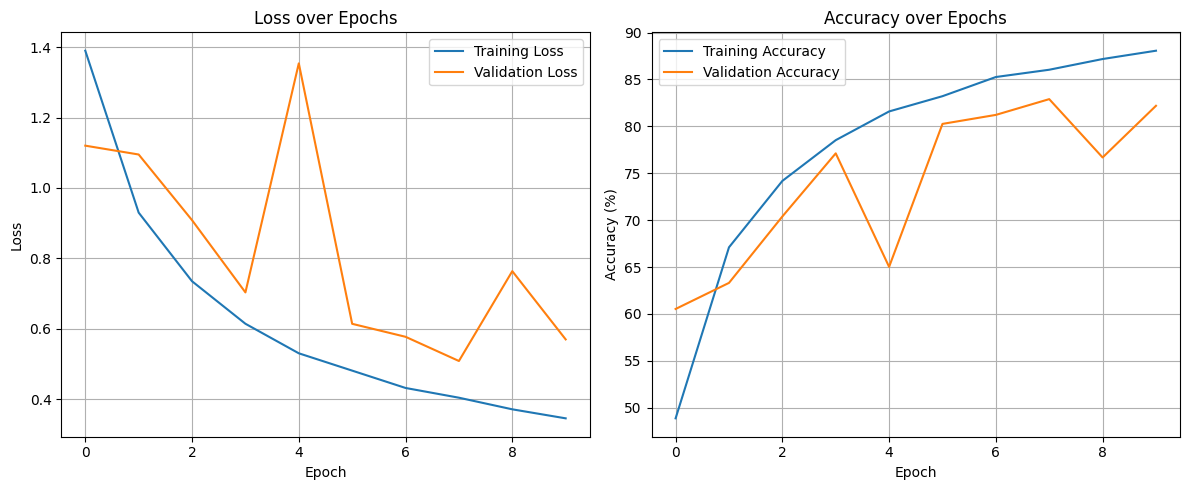

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()